<a href="https://colab.research.google.com/github/heoconngoc/Deep_Learning/blob/main/8_Modern_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Setup & Import

import math, time, os, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.9MB/s]


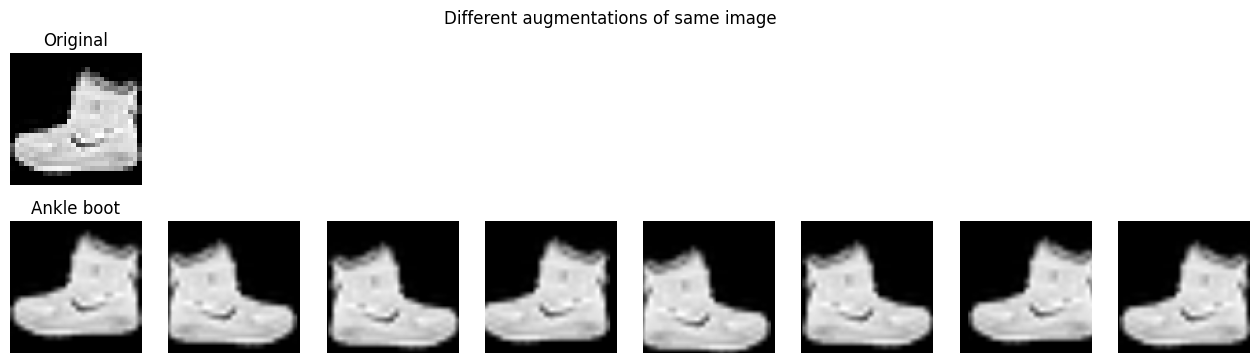

In [3]:
# Dataset & Augmentation Visualize

BATCH_SIZE = 128
IMG_SIZE = 96

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Resize all image into 96 x 96
    transforms.RandomCrop(IMG_SIZE, padding=8),
    # Add 8 pixels padding around img, then randomly crop it into 96x96. Data augmentation.
    # This helps the model withstand displacement of the object.

    transforms.RandomHorizontalFlip(), # Random flip img with prob = 50%. Data augmentation, decrease overfitting
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
]) # Compose many tranformation function into 1 pipeline

test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds = datasets.FashionMNIST(root="data", train=True, download=True, transform=train_tf)
test_ds  = datasets.FashionMNIST(root="data", train=False, download=True, transform=test_tf)

train_subset = Subset(train_ds, range(12000))
test_subset  = Subset(test_ds, range(3000))

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

classes = train_ds.classes

def show_augments(dataset, n=8):
    # get 1 original img (not augument) to compare -> use test_tf without randomness
    base_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    raw_ds = datasets.FashionMNIST(root="data", train=True, download=True, transform=None)
    img, label = raw_ds[0]

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))

    def denorm(x): return (x*0.5 + 0.5).clamp(0,1)

    # Original image
    axes[0,0].imshow(img, cmap="gray")
    axes[0,0].set_title("Original")
    axes[0,0].axis("off")

    for i in range(1, n):
        axes[0,i].axis("off")

    # Augmented versions
    for i in range(n):
        xa = train_tf(img)

        axes[1,i].imshow(denorm(xa)[0], cmap="gray")
        axes[1,i].axis("off")

        if i == 0:
            axes[1,i].set_title(classes[label])

    plt.suptitle("Different augmentations of same image")
    plt.show()

show_augments(train_ds, n=8)

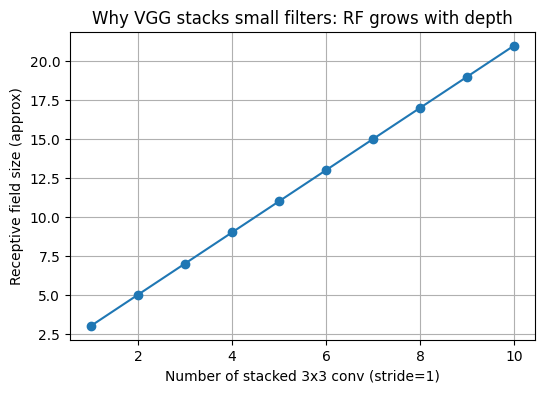

In [4]:
# Receptive Field demo (stack 3x3)
def receptive_field_3x3(num_layers):
    # RF recursion: RF_0 = 1
    # RF_{l+1} = RF_l + (k-1) * jump, with k=3, jump=1 if stride=1
    rf = 1
    for _ in range(num_layers):
        rf = rf + (3 - 1) * 1
    return rf

layers = list(range(1, 11))
rfs = [receptive_field_3x3(l) for l in layers]

plt.figure(figsize=(6,4))
plt.plot(layers, rfs, marker="o")
plt.xlabel("Number of stacked 3x3 conv (stride=1)")
plt.ylabel("Receptive field size (approx)")
plt.title("Why VGG stacks small filters: RF grows with depth")
plt.grid(True)
plt.show()

Main idea of VGGNet: Instead of using 1 big kernel 7x7, VGG used many small 3x3 kernel.

It is better due to: 1) Smaller number of params 2) More non-linearity (Each conv has ReLU and BatchNorm => More layer, more strength)

In [11]:
# Model zoo (LeNet/ AlexNet-lite/ ResNet-lite) + BatchNormal toggle

class LeNetBN(nn.Module):
    def __init__(self, use_bn=False):
        super().__init__()
        def conv_block(cin, cout):
          conv = nn.Conv2d(cin, cout, 5, padding=2)
          bn = nn.BatchNorm2d(cout) if use_bn else nn.Identity()
          relu = nn.ReLU()
          pool = nn.AvgPool2d(2)

          return nn.Sequential(conv, bn, relu, pool)

        self.features = nn.Sequential(
            conv_block(1, 6),
            conv_block(6, 16),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*(IMG_SIZE//4)*(IMG_SIZE//4), 120, bias=not use_bn),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class AlexNetLite(nn.Module):
    def __init__(self, use_bn=True):
        super().__init__()
        def C(cin, cout, k, s=1, p=0):
            layers = [nn.Conv2d(cin, cout, k, stride=s, padding=p, bias=not use_bn)]
            if use_bn: layers.append(nn.BatchNorm2d(cout))
            layers.append(nn.ReLU())
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            C(1, 64, 11, s=4, p=2), nn.MaxPool2d(3,2),
            C(64, 192, 5, p=2),    nn.MaxPool2d(3,2),
            C(192, 384, 3, p=1),
            C(384, 256, 3, p=1),
            C(256, 256, 3, p=1),   nn.MaxPool2d(3,2),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((6,6)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256*6*6, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.head(self.features(x))


class ResidualBlock(nn.Module):
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(cout)

        self.shortcut = nn.Identity()
        if stride != 1 or cin != cout:
            self.shortcut = nn.Sequential(
                nn.Conv2d(cin, cout, 1, stride=stride, bias=False),
                nn.BatchNorm2d(cout)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class ResNetLite(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )
        self.layer1 = nn.Sequential(ResidualBlock(32, 32), ResidualBlock(32, 32))
        self.layer2 = nn.Sequential(ResidualBlock(32, 64, stride=2), ResidualBlock(64, 64))
        self.layer3 = nn.Sequential(ResidualBlock(64, 128, stride=2), ResidualBlock(128, 128))

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.head(x)

In [12]:
# Param count + FLOPs estimate (conv/ linear)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

@torch.no_grad()
def estimate_flops(model, input_shape=(1,1,IMG_SIZE,IMG_SIZE), device=device):
    model = model.to(device).eval()
    hooks = []
    flops = {"conv": 0, "linear": 0}

    def conv_hook(m, x, y):
        # x[0]: (N,Cin,H,W), y: (N,Cout,Hout,Wout)
        x0 = x[0]
        Cin = x0.shape[1]
        Cout = y.shape[1]
        Hout, Wout = y.shape[2], y.shape[3]
        kH, kW = m.kernel_size
        groups = m.groups
        # per output element multiplications: kH*kW*(Cin/groups)
        flops["conv"] += 2 * Hout * Wout * Cout * (kH * kW * (Cin // groups))

    def linear_hook(m, x, y):
        # x[0]: (N, in), y: (N, out)
        in_f = m.in_features
        out_f = m.out_features
        flops["linear"] += 2 * in_f * out_f

    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            hooks.append(m.register_forward_hook(conv_hook))
        elif isinstance(m, nn.Linear):
            hooks.append(m.register_forward_hook(linear_hook))

    dummy = torch.randn(*input_shape).to(device)
    _ = model(dummy)

    for h in hooks: h.remove()
    return flops

def human(n):
    for unit in ["", "K", "M", "B", "T"]:
        if abs(n) < 1000:
            return f"{n:.2f}{unit}"
        n /= 1000
    return f"{n:.2f}P"

LeNet params: 1.12M FLOPs: {'conv': '13.82M', 'linear': '2.23M'} total: 16.06M
LeNet+BN params: 1.12M FLOPs: {'conv': '13.82M', 'linear': '2.23M'} total: 16.06M
AlexNet-lite params: 7.18M FLOPs: {'conv': '189.44M', 'linear': '9.45M'} total: 198.89M
ResNet-lite params: 696.04K FLOPs: {'conv': '1.89B', 'linear': '2.56K'} total: 1.89B


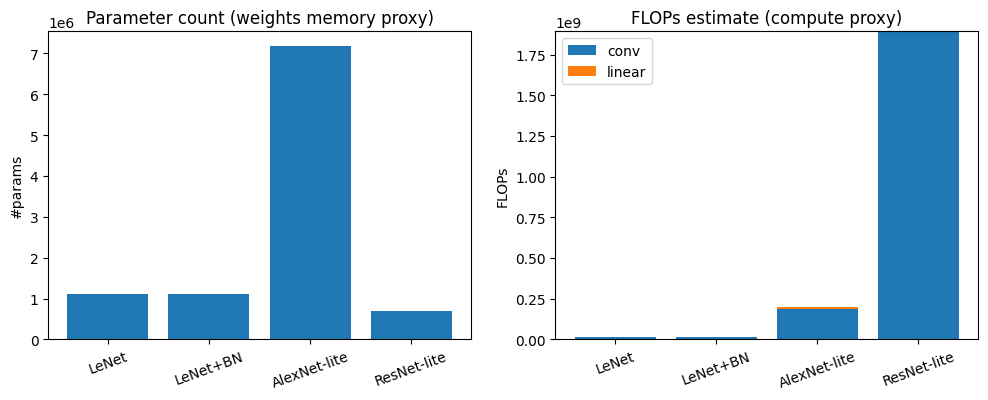

In [13]:
# Compare Params/ FLOPs bar chart

models = {
    "LeNet": LeNetBN(use_bn=False),
    "LeNet+BN": LeNetBN(use_bn=True),
    "AlexNet-lite": AlexNetLite(use_bn=True),
    "ResNet-lite": ResNetLite(),
}

stats = {}
for name, m in models.items():
    p = count_params(m)
    f = estimate_flops(m)
    stats[name] = (p, f["conv"], f["linear"], f["conv"]+f["linear"])
    print(name, "params:", human(p), "FLOPs:", {k: human(v) for k,v in f.items()}, "total:", human(f["conv"]+f["linear"]))

# plot
names = list(stats.keys())
params = [stats[n][0] for n in names]
flops_total = [stats[n][3] for n in names]
flops_conv = [stats[n][1] for n in names]
flops_fc   = [stats[n][2] for n in names]

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].bar(names, params)
ax[0].set_title("Parameter count (weights memory proxy)")
ax[0].tick_params(axis='x', rotation=20)
ax[0].set_ylabel("#params")

ax[1].bar(names, flops_conv, label="conv")
ax[1].bar(names, flops_fc, bottom=flops_conv, label="linear")
ax[1].set_title("FLOPs estimate (compute proxy)")
ax[1].tick_params(axis='x', rotation=20)
ax[1].set_ylabel("FLOPs")
ax[1].legend()
plt.show()


==> LeNet
ep 01 | 7.0s | train acc 0.573 test acc 0.757
ep 02 | 8.1s | train acc 0.741 test acc 0.793

==> LeNet+BN
ep 01 | 6.3s | train acc 0.689 test acc 0.779
ep 02 | 7.4s | train acc 0.782 test acc 0.816

==> AlexNet-lite
ep 01 | 6.3s | train acc 0.451 test acc 0.668
ep 02 | 7.5s | train acc 0.658 test acc 0.688

==> ResNet-lite
ep 01 | 37.0s | train acc 0.597 test acc 0.103
ep 02 | 33.4s | train acc 0.758 test acc 0.386


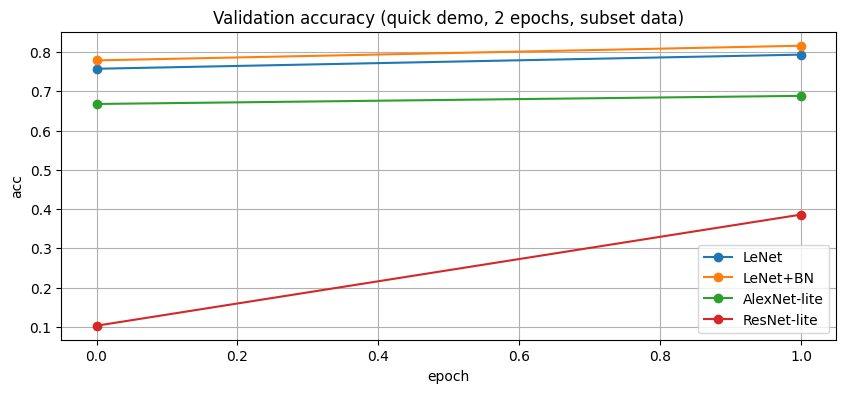

In [14]:
# Train/ Eval loops

def accuracy(logits, y):
    return (logits.argmax(1) == y).float().mean().item()

def run_epoch(model, loader, optim=None):
    train = optim is not None
    model.train(train)
    total_loss, total_acc, n = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        if train:
            optim.zero_grad()
            loss.backward()
            optim.step()
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc  += (logits.argmax(1) == y).float().sum().item()
        n += bs

    return total_loss/n, total_acc/n

def train_model(model, epochs=2, lr=1e-3):
    model = model.to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss":[], "train_acc":[], "test_loss":[], "test_acc":[]}

    for ep in range(1, epochs+1):
        t0 = time.time()
        trL, trA = run_epoch(model, train_loader, optim)
        teL, teA = run_epoch(model, test_loader, None)
        dt = time.time()-t0
        history["train_loss"].append(trL); history["train_acc"].append(trA)
        history["test_loss"].append(teL);  history["test_acc"].append(teA)
        print(f"ep {ep:02d} | {dt:.1f}s | train acc {trA:.3f} test acc {teA:.3f}")
    return history

histories = {}
for name in ["LeNet", "LeNet+BN", "AlexNet-lite", "ResNet-lite"]:
    print("\n==>", name)
    histories[name] = train_model(models[name], epochs=2, lr=1e-3)

# plot curves
plt.figure(figsize=(10,4))
for name,h in histories.items():
    plt.plot(h["test_acc"], marker="o", label=name)
plt.title("Validation accuracy (quick demo, 2 epochs, subset data)")
plt.xlabel("epoch"); plt.ylabel("acc"); plt.grid(True); plt.legend()
plt.show()

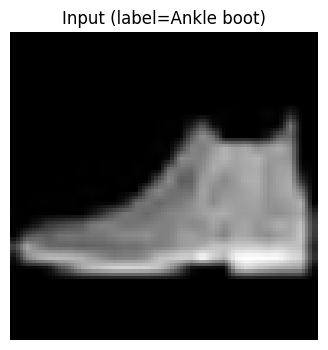

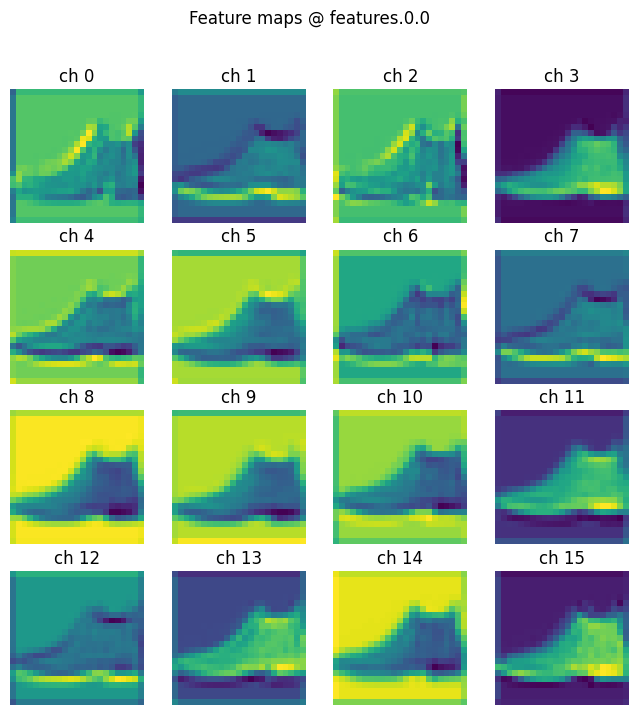

In [16]:
# Visuallize feature map (Conv1)

@torch.no_grad()
def visualize_feature_maps(model, layer_name="features.0.0", idx=0, n_maps=16):
    model = model.to(device).eval()
    # get a batch
    x, y = next(iter(test_loader))
    x = x.to(device)
    img = x[idx:idx+1]

    # hook get activation
    acts = {}
    def hook(module, inp, out):
        acts["fm"] = out.detach().cpu()

    # find layer
    target = dict(model.named_modules())[layer_name]
    h = target.register_forward_hook(hook)
    _ = model(img)
    h.remove()

    fm = acts["fm"][0]  # (C,H,W)
    C = fm.shape[0]
    n = min(n_maps, C)

    def denorm(x): return (x*0.5 + 0.5).clamp(0,1)

    plt.figure(figsize=(4,4))
    plt.imshow(denorm(img.cpu()[0])[0], cmap="gray")
    plt.title(f"Input (label={classes[y[idx]]})")
    plt.axis("off")
    plt.show()

    cols = int(math.sqrt(n))
    rows = math.ceil(n/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))
    axes = axes.flatten()
    for i in range(n):
        axes[i].imshow(fm[i], cmap="viridis")
        axes[i].axis("off")
        axes[i].set_title(f"ch {i}")
    for i in range(n, len(axes)):
        axes[i].axis("off")
    plt.suptitle(f"Feature maps @ {layer_name}")
    plt.show()

# With AlexNet-lite, layer_name conv1 is 'features.0.0'
visualize_feature_maps(models["AlexNet-lite"], layer_name="features.0.0", n_maps=16)

=== NO BN ===
mean=-0.0819, var=0.1042, std=0.3228
=== WITH BN ===
mean=-0.0463, var=0.1732, std=0.4162


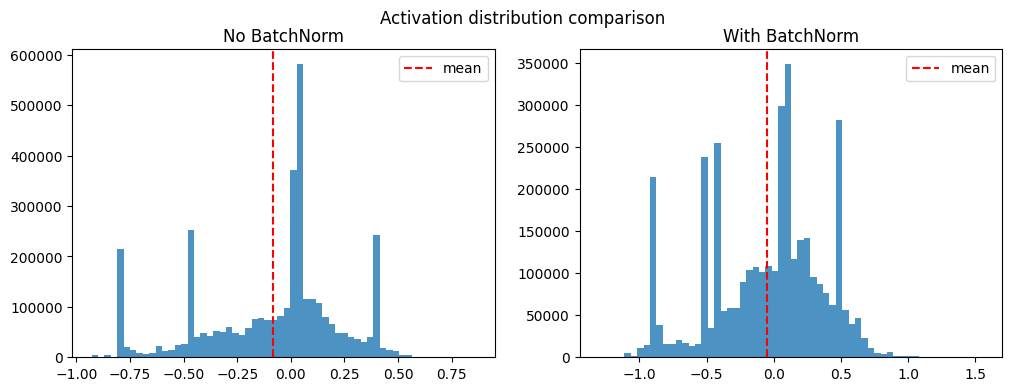

In [18]:
# Batch Normalization: Histogram activation

@torch.no_grad()
def bn_hist_demo():
    model_no = LeNetBN(use_bn=False).to(device).eval()
    model_bn = LeNetBN(use_bn=True).to(device).eval()

    x, y = next(iter(test_loader))
    x = x.to(device)[:64]

    def get_act(model):
        acts = {}

        def hook(m, inp, out):
            acts["a"] = out.detach().cpu().flatten()

        h = model.features[0][1].register_forward_hook(hook)
        _ = model(x)
        h.remove()
        return acts["a"]

    a_no = get_act(model_no)
    a_bn = get_act(model_bn)

    # ===== statistics =====
    def stats(a):
        return a.mean().item(), a.var().item(), a.std().item()

    mean_no, var_no, std_no = stats(a_no)
    mean_bn, var_bn, std_bn = stats(a_bn)

    print("=== NO BN ===")
    print(f"mean={mean_no:.4f}, var={var_no:.4f}, std={std_no:.4f}")

    print("=== WITH BN ===")
    print(f"mean={mean_bn:.4f}, var={var_bn:.4f}, std={std_bn:.4f}")

    # ===== plot =====
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(a_no.numpy(), bins=60, alpha=0.8)
    plt.axvline(mean_no, color="red", linestyle="--", label="mean")
    plt.title("No BatchNorm")
    plt.legend()

    plt.subplot(1,2,2)
    plt.hist(a_bn.numpy(), bins=60, alpha=0.8)
    plt.axvline(mean_bn, color="red", linestyle="--", label="mean")
    plt.title("With BatchNorm")
    plt.legend()

    plt.suptitle("Activation distribution comparison")
    plt.show()

bn_hist_demo()

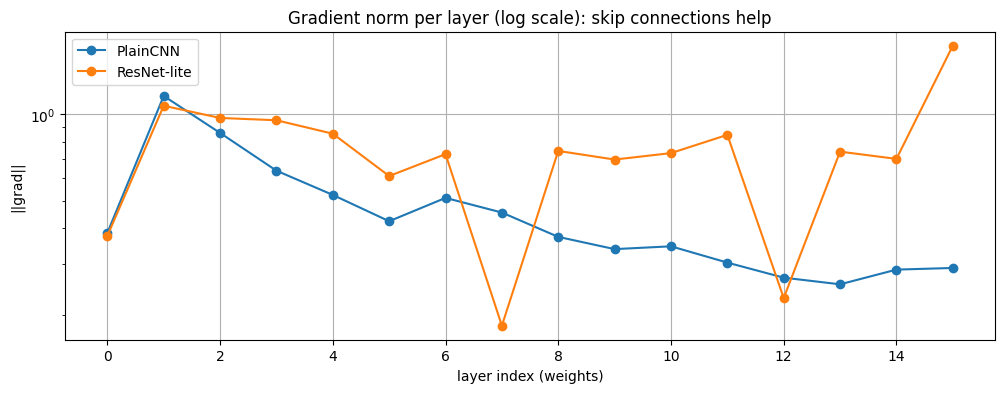

In [20]:
# Vanishing gradient demo: Plain CNN vs ResNet-lite

class PlainCNN(nn.Module):
    def __init__(self):
        super().__init__()
        layers = []
        cin = 1
        for i in range(15):  # deeper to easily see
            cout = 32 if i < 5 else 64
            stride = 2 if i in [4, 7] else 1
            layers += [nn.Conv2d(cin, cout, 3, stride=stride, padding=1, bias=False),
                       nn.BatchNorm2d(cout),
                       nn.ReLU()]
            cin = cout
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(), nn.Linear(cin, 10))

    def forward(self, x):
        x = self.features(x)
        return self.head(x)

def grad_norms(model):
    model = model.to(device).train()
    x, y = next(iter(train_loader))
    x, y = x.to(device)[:64], y.to(device)[:64]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    model.zero_grad()
    loss.backward()

    norms = []
    names = []
    for n, p in model.named_parameters():
        if p.grad is not None and p.ndim >= 2:  # weight tensors
            norms.append(p.grad.detach().norm().item())
            names.append(n)
    return names, norms

plain = PlainCNN()
res   = ResNetLite()

n1, g1 = grad_norms(plain)
n2, g2 = grad_norms(res)

plt.figure(figsize=(12,4))
plt.plot(g1, label="PlainCNN", marker="o")
plt.plot(g2, label="ResNet-lite", marker="o")
plt.yscale("log")
plt.title("Gradient norm per layer (log scale): skip connections help")
plt.xlabel("layer index (weights)")
plt.ylabel("||grad||")
plt.grid(True)
plt.legend()
plt.show()